# Trees

The {class}`~neurosetta.api.Tree` class is the core handle for one neuron morphology.

See {doc}`../getting_started/io` for loading files.


In [1]:
import neurosetta as nr
import numpy as np

tree = nr.load_example_data(nr.example_ids[0])
tree.summary()


ID,nodes,branches,leaves,cable,units,isReduced,Flag
720575940596125868,2010,99,111,404.2,micron,False,False


## Tree Core Attributes

All `Trees` in NeuRosetta have three core attributes: ID, metadata, and graph. The ID is dervied directly from the import file. This is because typically in connectomics data individual neurons will have a unique integer ID. This is what is used in NeuRosetta.

It is worth noting that unlike other some other toolboxes in python, you cannot add arbritrary properties to instances of the `Tree` class:

In [2]:
tree.my_property = 'test'

AttributeError: 'Tree' object has no attribute 'my_property'

This is because we use `__slots__` in the class definitions to lower the memory footprint when you are handling many neurons at once. Instead of this, there are two ways to add information to a `Tree`, via the `metadata` or through bound properties.

### Metadata

The core fields in the metadata are `['units','file_path','isReduced','Flag']`. These entries in the metadata are protected, so cannot be modified directly. 

Protected entries:

|key|dtype|purpose|
|-|-|-|
|`units`|str|spatial units of the neuron|
|`file_path`|str|path to file on disk|
|`Flag`|bool|set flag state of the neuron, can be set through GUI. |
|`isReduced`|bool|If the `Tree` has been 'reduced'|

You can get individual metadta entries:

In [3]:
tree.get_meta(key = 'isReduced')

False

You can add and remove entries to the metadata easily. Importantly, the `.nr` file type will preserve these on save. You can view the metadata easily:

In [4]:
tree.set_meta(key = 'example', value = 'test')
tree.metadata

{'units': 'micron', 'file_path': '/home/ndrummond@neuro.mpg.de/Code/NeuRosetta/docs/data/nr/720575940596125868.nr', 'isReduced': False, 'Neuron_type': 'T5', 'Neuron_subtype': 'c', 'Hemisphere': 'R', 'Flag': False, 'example': 'test'}

and remove entries (not the protected ones!):

In [5]:
tree.del_meta(key = 'example')
tree.metadata

{'units': 'micron', 'file_path': '/home/ndrummond@neuro.mpg.de/Code/NeuRosetta/docs/data/nr/720575940596125868.nr', 'isReduced': False, 'Neuron_type': 'T5', 'Neuron_subtype': 'c', 'Hemisphere': 'R', 'Flag': False}

In order to keep track of what has been added to `tree.metadata` you can list the current keys:

In [6]:
tree.list_meta()

['Hemisphere', 'Neuron_subtype', 'Neuron_type']

### Graph Properties

The otherr way to store information with a `Tree` is through the use of properties. Thess come from `graph-tool` and are related to `tree.graph`. You can read about what is going on under the hood [here](https://graph-tool.skewed.de/static/docs/stable/quickstart.html#property-maps). 

Tree properties are available at three levels: `['g','v','e']`. These can also be called:

|level|aliases|description|
|-|-|-|
|'g'|'graph'|Properties of the whole graph|
|'v'|'vertex','v','n'|Properties on single nodes|
|'e'|'edge'|Prroperties on single edges|

You can list properties from a tree at a specific level, or globaly:


In [7]:
tree.list_properties()

{'g': ['ID', 'metadata'],
 'v': ['ids',
  'x',
  'y',
  'z',
  'node_type',
  'radius',
  'subgraph_score',
  'v_subtree_mask'],
 'e': ['Path_length', 'e_subtree_mask']}

In [8]:
tree.list_properties(level = 'g')

['ID', 'metadata']

There are some properties *all* `Tree` objects have in NeuRosetta:

| Level | Property | Description |
|---|---|---|
| `g` | ID | The integer ID of the tree |
| `g` | metadata | How the metadata described above is stored |
| `v` | ids | The node IDs from the import file |
| `v` | x | x coordinates |
| `v` | y | y coordinates |
| `v` | z | z coordinates |
| `v` | radius | Radius at the node |
| `v` | node_type | Node type |
| `e` | Path_length | Length of the edge in `metadata.units` |

> **Note on `ids`:** These IDs come from how a neuron is imported from an `swc`
> file. They may change and do not correspond to the indexing of nodes. They
> have little practical use, but are retained because they are part of the
> import data.

> **Note on `node_type`:** The node type comes from `swc` files and follows the
> node type convention described
> [here](http://www.neuronland.org/NLMorphologyConverter/MorphologyFormats/SWC/Spec.html).
> `0` is *undefined*, `-1` is the root (this differs from the SWC specification),
> `5` is a branch node, and `6` is a terminal node. NeuRosetta does not use this
> property directly; it is retained for consistency.

A few other things to note:

NeuRosetta uses a [Series of arrays (SoA)](https://en.wikipedia.org/wiki/AoS_and_SoA) format under the hood to handle coordinates, so stores them as 3 by n arrays, rather than a single n by 3 array.

If a neuron is only ever seen by NeuRosetta with `isReduced == True` in the metadata, then the 'Path_length' property will be called 'Euclidean_length' as NeuRosetta cannot assume the distance between nodes in a reduced rerpresentation is the actual length of cable in the reconstruction, and really probably isn't. Have a look at {doc}`tree_surgery` to read about the reduced tree representation.

#### Getting properties

Using `get_property` will fetch the values of a property, in the below example returning an array of each nodes radius:

In [9]:
tree.get_property(name = 'radius')[:5]

PropertyArray([0.53351143, 0.6488706 , 0.85276616, 0.99388029, 1.11411054])

Accessing coordinates have their own function/method however, because of the above mentioned SoA thing. Fetching the coordinate array in SoA format is turned off by default, but available optionally:

In [10]:
tree.get_node_coordinates(SoA = False)

array([[723.45567568, 274.77648649, 242.55340541],
       [723.589     , 274.7245    , 242.466     ],
       [723.72513559, 274.65722034, 242.37132203],
       ...,
       [705.159     , 274.0815    , 219.9225    ],
       [705.789     , 274.134     , 219.387     ],
       [705.138     , 274.071     , 219.912     ]], shape=(2010, 3))

You can also check if a tree has a property:

In [11]:
tree.has_property('radius')

True

### Setting properties

Properties can be created and modified for a tree using the `set_property` function/method. You can do this by passing your data to `set_property`. Keep in mind that when ssetting properties at the 'v' or 'e' level, the given data must have the same number of entries as nodes or edges within the tree.

To update existing properties:

In [12]:
# show the old property values
print(tree.get_property("radius")[:5])
# create new data and update property values
data = np.zeros(tree.count_nodes())
tree.set_property(name="radius", data=data, level="v")
print(tree.get_property("radius")[:5])


[0.53351143 0.6488706  0.85276616 0.99388029 1.11411054]
[0. 0. 0. 0. 0.]


You can also create new properties. When creating new properties, `set_property` need to be told that is what it is doing, so the `create == True`. Also, as properties are tied to the underlying C++ `graph_tool.Graph` object, you need to specify the datatype using `dtype`. There is a table of datatype aliases for `graph_tool` [here](https://graph-tool.skewed.de/static/docs/stable/quickstart.html#property-maps).

To make a new property:

In [13]:
data = np.ones(tree.count_nodes())
tree.set_property(name="ones", data=data, level="v", create=True, dtype="int")
print(tree.get_property("ones")[:5])

[1 1 1 1 1]


Properties can then be deleted using `del_property`:

In [14]:
tree.del_property(name = 'ones', level = 'v')
tree.get_property('ones')

KeyError: "Property 'ones' not found at any level (g/v/e)"

#### The `bind` Argument

Many functions in NeuRosetta have a `bind` argument. With any function that has this, and when `bind == True`, the function won't return anything, but will attach the result of the function directly to the `Tree` as a property. 

The name of the property will be described in the functions doc string, so refer to this. 

Importantly, any bound properties on a tree will be saved with the `nr` file, and preserved across sessions.

## Reduced Trees

A full Neuron tree-graph representation typically has a bunch of nodes within it which have a single in edge and a single out edge. This gives individual sections their rich curvature and geometry in space.

In the example neuron we have currenty loaded, for example, only $\sim1\%$ of the nodes in the neuron are not these transitive nodes. Non-transitive nodes, the neuron root, branch points, and leaves, NeuRosetta terms as the 'core' nodes. These are the nodes which hold the most information about the neurons actual morphology (arguably).

In many instances in fact, the $\sim99\%$ transitive nodes are not realy needed. As such, NeuRosetta has a reduced neuron representations which removes thes transitive nodes. This *dramatically* reduces the memory footprint of neurons, as well as the ammount of time needed to do many opperations.

If a `Tree` is reduced is kept in `tree.metadata`, and can be checked using:

In [15]:
tree.is_reduced()

False

If you think a `Tree` should be flagged as reduced but for whatever reason isn't you can update the reduced property by checking if the tree has any transitive nodes using:

In [16]:
tree.update_reduced()

Some properties (specifically, `Path_length`) change when a tree is reduced or not. If you remove all the transitive nodes, you cannot callculate the actual path length any more.

Once a `Tree` is read into NeuRosetta, it should get the 'Path_length' edge property by default. If you have a tree without this property you can add it:

If you do this with a reduced `Tree` however, the property 'Path_length' is not created, and rather a different one called 'Euclidean_length' is created. This means the 'Path_length' property persists as the True measurement, regardless of it a `Tree` is reduced or not. This preserves elements such as the total cable length after a `Tree` has been reduced. 

Below is a small example illustrating how reduction works and visualising the result:

Total Cable Length: 404.24 micron
isRecuced? False
Has 'Path_length'? True
Has 'Euclidean_length'? False


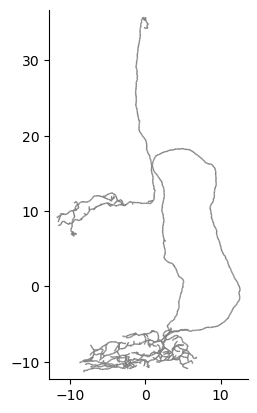

In [17]:
tree.show_2d()
print(f"Total Cable Length: {tree.get_total_cable_length():.2f} {tree.get_units()}")
print(f"isRecuced? {tree.is_reduced()}")
print(f"Has 'Path_length'? {tree.has_property('Path_length')}")
print(f"Has 'Euclidean_length'? {tree.has_property('Euclidean_length')}")


Total Cable Length: 404.24 micron
isRecuced? True
Has 'Path_length'? True
Has 'Euclidean_length'? True


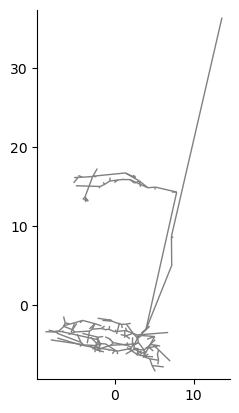

In [18]:
red_tree = tree.copy()
nr.reduce_tree(red_tree, inplace = True)
# note that ou have to explicitly add the 'Euclidean_length' property should you want it
red_tree.get_edge_length(bind = True, recalculate = True)
red_tree.show_2d()
print(f"Total Cable Length: {red_tree.get_total_cable_length():.2f} {red_tree.get_units()}")
print(f"isRecuced? {red_tree.is_reduced()}")
print(f"Has 'Path_length'? {red_tree.has_property('Path_length')}")
print(f"Has 'Euclidean_length'? {red_tree.has_property('Euclidean_length')}")

## Spatial Units

NeuRosetta handles spatial units using [Pint](https://pint.readthedocs.io/en/stable/) under the hood. Have a look at {doc}`../reference/metrics` for an overview. 

NeuRosetta assumes, unless otherwise specified or stored in a neurons metadata, that the spatial units of a neuron are `dimensionless` by default. NeuRosetta can hande both continuous units (microns, nanometers) or voxel units. 


When importing or loading `swc` or `nr` files, you have the `set_units = <unit string>` argument if you know the units, or alternatively `voxel_size = <float>` and `voxel_unit = <unit string>` to specify voxel units. If you import/load neurons which are dimensionless, you can set units using `tree.set_units()`

If you can spatial units:

In [19]:
tree.get_units()

'micron'

Or convert units:

In [20]:
tree.convert_units('nm')
tree.get_units()

'nanometer'

Unit conversion will automatically convert coordinates, radii, and path/euclidean lengths.

<Axes: >

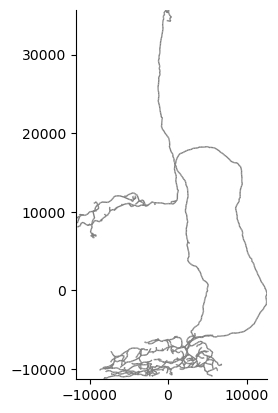

In [21]:
tree.show_2d()

You can also convert to voxel units:

In [27]:
tree.convert_units(voxel_size = 8, voxel_unit='um')

Tree(ID=720575940596125868) with 2010 nodes

Notice that this example of 8 micron vovels is sort of ridiculous, however when you plot the neuron it looks the same:

<Axes: >

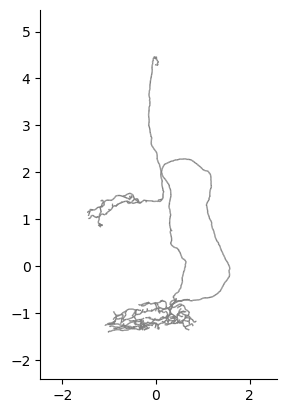

In [28]:
tree.show_2d()

This is because voxel coordinates are transformed, but still treated as continuous. You can snap the coordinates of neurons in voxel units to the voxels like so, which plots a stupid low resolution neuron:

<Axes: >

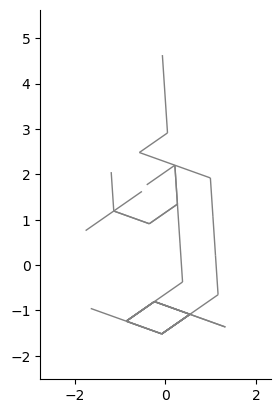

In [30]:
tree.snap_voxel_coordinates()
tree.show_2d()

### Functions vs Methods

Every tree method mirrors a function in {doc}`../api/tree_ops/index`. This means that `tree.do_something() == nr.do_something(tree)`. Have a look at {doc}`../reference/metrics` where we try to keep an up to date list of implemented metrics for neurons.

Next: {doc}`forests`.
